#Dimensionality Reduction and Behavioral Clustering for Academic Intervention

# EXPLORATORY DATA ANALYSIS

<div style="background-color: black|; padding: 10px; border-radius: 5px;">
    

Exploratory Data Analysis (EDA) is a critical first step before starting clustering to understand the structure, relationships, and characteristics of the dataset. Here’s how to perform EDA for clustering:

1. Data Overview: Start by examining the dataset for size, data types, and missing values. Check the number of features and samples to understand the dataset's complexity.

2. Missing Data Handling: Identify and handle missing values through imputation or removal to ensure clustering algorithms can process the data accurately.

3. Visualizations: Use pair plots, heatmaps, and scatter plots to explore relationships and clusters within the data visually.
    
    </div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score

In [2]:
pip install kneed

## Import Data


In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/royhandaus/data_mining_royhan/refs/heads/main/Student%20Dropout%20Behaviour/Dataset/student_dropout_behavior_dataset.csv")
df.head()

,student_id,name,age,gender,quiz1_marks,quiz2_marks,quiz3_marks,total_assignments,assignments_submitted,midterm_marks,final_marks,previous_gpa,total_lectures,lectures_attended,total_lab_sessions,labs_attended
0,1,Kristina Vaughan,19,Male,8.0,5.7,7.4,5,NaN,30.0,36.5,2.57,12,4,6,1
1,2,Rodney Daniels,21,Male,10.0,7.9,4.1,5,NaN,25.4,33.0,2.40,12,1,6,5
2,3,Jose Nash,19,Female,7.5,1.2,0.3,5,NaN,14.4,24.8,2.99,12,0,6,0
3,4,Nicole Martin,21,Male,5.2,2.5,9.9,5,NaN,17.7,41.0,1.68,12,9,6,0
4,5,Shelby Smith,21,Female,5.9,6.3,2.0,5,NaN,23.8,31.0,2.53,12,7,6,4


## Check for missing values

In [4]:
print(df.isnull().sum())

student_id                 0
name                       0
age                        0
gender                     0
quiz1_marks                0
quiz2_marks                0
quiz3_marks                0
total_assignments          0
assignments_submitted    300
midterm_marks              0
final_marks                0
previous_gpa               0
total_lectures             0
lectures_attended          0
total_lab_sessions         0
labs_attended              0
dtype: int64


## Check Unique Value

In [5]:
print("Unique values for assignment_submitted:", df['assignments_submitted'].unique())
print("Unique values for name:", df['name'].unique())
print("Unique values for student_id:", df['student_id'].unique())
print("Unique values for gender:", df['gender'].unique())
print("Unique values for total_assignment:", df['total_assignments'].unique())
print("Unique values for total_lectures:", df['total_lectures'].unique())
print("Unique values for total_lab_sessions:", df['total_lab_sessions'].unique())

Unique values for assignment_submitted: [nan]
Unique values for name: ['Kristina Vaughan' 'Rodney Daniels' 'Jose Nash' 'Nicole Martin'
 'Shelby Smith' 'Austin Griffin' 'Crystal Jordan' 'Sandra Patterson'
 'Rachael Miles' 'Matthew Rice' 'Lawrence Powers' 'Joshua Henry'
 'Jamie Jones' 'Rita Olson' 'Matthew Williams' 'Terry Little'
 'Doris Larson' 'Gregg Gonzales' 'Pamela Jones' 'Mark Allen'
 'Sherri Wheeler' 'Jeffrey Martin' 'Sandra Smith' 'Colton Bradley'
 'Amy Johnson' 'Ryan Lyons' 'Dr. Andrew Chang' 'Michael Williamson Jr.'
 'Jessica Hart' 'Stephanie Gonzales' 'Dr. Jamie Mclaughlin' 'Diana Martin'
 'Jessica Russell' 'Christopher Buchanan' 'Sean Bates' 'Stephen Khan'
 'Patricia Macias' 'Michael Davis' 'Richard Savage' 'Maria Pennington'
 'Stephanie Yoder' 'Maria Rasmussen' 'Melanie Cox' 'Carol Walls'
 'Brandon Garcia' 'David Williams' 'Eric Hodge' 'Daniel Nguyen'
 'Elizabeth Cook' 'Tracy Myers' 'Ernest Payne' 'Richard Rich'
 'Jonathan Francis' 'Olivia Jones' 'Ernest Allen' 'Jacob Ramir

## Drop Column

In [6]:
Drop_kolom = ['assignments_submitted', 'name', 'student_id','total_assignments','total_lectures','total_lab_sessions']
df_cleaned = df.drop(columns=Drop_kolom)
df_cleaned.head()

,age,gender,quiz1_marks,quiz2_marks,quiz3_marks,midterm_marks,final_marks,previous_gpa,lectures_attended,labs_attended
0,19,Male,8.0,5.7,7.4,30.0,36.5,2.57,4,1
1,21,Male,10.0,7.9,4.1,25.4,33.0,2.40,1,5
2,19,Female,7.5,1.2,0.3,14.4,24.8,2.99,0,0
3,21,Male,5.2,2.5,9.9,17.7,41.0,1.68,9,0
4,21,Female,5.9,6.3,2.0,23.8,31.0,2.53,7,4


<span style="color: blue; font-style: italic;">No missing value in this data, good to proceed with descriptive analytics!</span>



## Check Data Information



In [7]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                300 non-null    int64  
 1   gender             300 non-null    object 
 2   quiz1_marks        300 non-null    float64
 3   quiz2_marks        300 non-null    float64
 4   quiz3_marks        300 non-null    float64
 5   midterm_marks      300 non-null    float64
 6   final_marks        300 non-null    float64
 7   previous_gpa       300 non-null    float64
 8   lectures_attended  300 non-null    int64  
 9   labs_attended      300 non-null    int64  
dtypes: float64(6), int64(3), object(1)
memory usage: 23.6+ KB


## Descriptive Statistics

In [8]:
df.describe()

,student_id,age,quiz1_marks,quiz2_marks,quiz3_marks,total_assignments,assignments_submitted,midterm_marks,final_marks,previous_gpa,total_lectures,lectures_attended,total_lab_sessions,labs_attended
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.0,0.0,300.000000,300.000000,300.000000,300.0,300.000000,300.0,300.000000
mean,150.500000,21.550000,7.254667,5.866667,5.469000,5.0,NaN,19.969000,37.375000,2.806033,12.0,6.013333,6.0,3.110000
std,86.746758,2.241483,1.611791,2.414786,2.711083,0.0,NaN,8.272229,11.796774,0.732694,0.0,3.726407,0.0,1.982676
min,1.000000,18.000000,2.800000,0.000000,0.000000,5.0,NaN,0.000000,0.000000,0.610000,12.0,0.000000,6.0,0.000000
25%,75.750000,20.000000,6.075000,4.000000,3.600000,5.0,NaN,14.225000,29.875000,2.327500,12.0,3.000000,6.0,1.000000
50%,150.500000,22.000000,7.300000,5.800000,5.600000,5.0,NaN,21.350000,39.600000,2.800000,12.0,6.000000,6.0,3.000000
75%,225.250000,23.000000,8.400000,7.700000,7.200000,5.0,NaN,27.425000,49.550000,3.320000,12.0,9.000000,6.0,5.000000
max,300.000000,25.000000,10.000000,10.000000,10.000000,5.0,NaN,30.000000,50.000000,4.000000,12.0,12.000000,6.0,6.000000


In [9]:
df_cleaned.describe()

,age,quiz1_marks,quiz2_marks,quiz3_marks,midterm_marks,final_marks,previous_gpa,lectures_attended,labs_attended
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,21.550000,7.254667,5.866667,5.469000,19.969000,37.375000,2.806033,6.013333,3.110000
std,2.241483,1.611791,2.414786,2.711083,8.272229,11.796774,0.732694,3.726407,1.982676
min,18.000000,2.800000,0.000000,0.000000,0.000000,0.000000,0.610000,0.000000,0.000000
25%,20.000000,6.075000,4.000000,3.600000,14.225000,29.875000,2.327500,3.000000,1.000000
50%,22.000000,7.300000,5.800000,5.600000,21.350000,39.600000,2.800000,6.000000,3.000000
75%,23.000000,8.400000,7.700000,7.200000,27.425000,49.550000,3.320000,9.000000,5.000000
max,25.000000,10.000000,10.000000,10.000000,30.000000,50.000000,4.000000,12.000000,6.000000


In [10]:
df_cleaned.head()

,age,gender,quiz1_marks,quiz2_marks,quiz3_marks,midterm_marks,final_marks,previous_gpa,lectures_attended,labs_attended
0,19,Male,8.0,5.7,7.4,30.0,36.5,2.57,4,1
1,21,Male,10.0,7.9,4.1,25.4,33.0,2.40,1,5
2,19,Female,7.5,1.2,0.3,14.4,24.8,2.99,0,0
3,21,Male,5.2,2.5,9.9,17.7,41.0,1.68,9,0
4,21,Female,5.9,6.3,2.0,23.8,31.0,2.53,7,4


## Encoding

In [11]:
from sklearn.preprocessing import LabelEncoder

# Re-initialize df_encoded from df to ensure original 'ocean_proximity' column is present
df_encoded = df_cleaned.copy()

# Create a LabelEncoder instance
le = LabelEncoder()

# Apply Label Encoding to the 'ocean_proximity' column
df_encoded['gender'] = le.fit_transform(df_encoded['gender'])

# Display the head of the transformed DataFrame to verify
df_encoded.head()

,age,gender,quiz1_marks,quiz2_marks,quiz3_marks,midterm_marks,final_marks,previous_gpa,lectures_attended,labs_attended
0,19,1,8.0,5.7,7.4,30.0,36.5,2.57,4,1
1,21,1,10.0,7.9,4.1,25.4,33.0,2.40,1,5
2,19,0,7.5,1.2,0.3,14.4,24.8,2.99,0,0
3,21,1,5.2,2.5,9.9,17.7,41.0,1.68,9,0
4,21,0,5.9,6.3,2.0,23.8,31.0,2.53,7,4


# Visualize

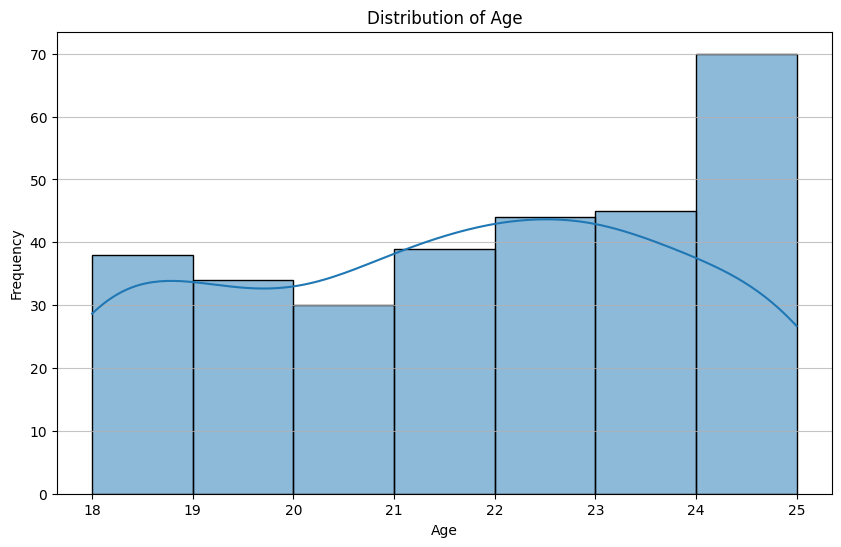

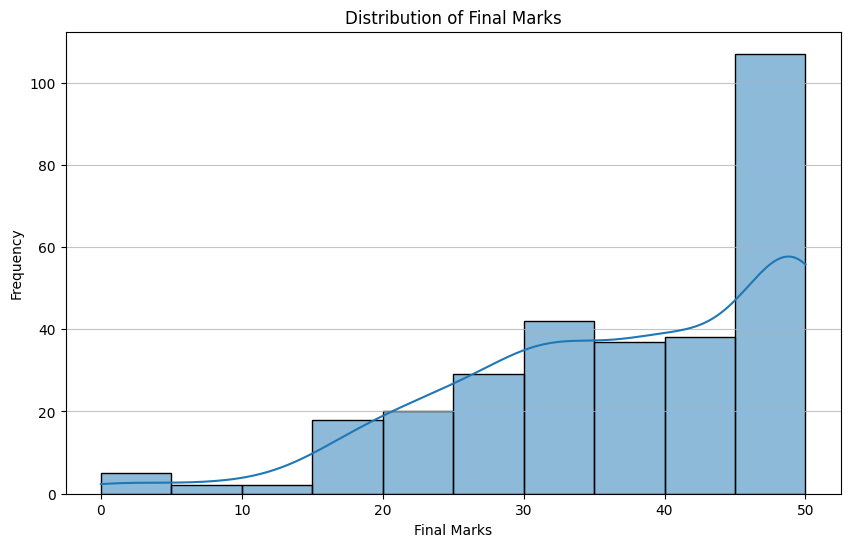

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize 'age' distribution with a histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['age'], kde=True, bins=7)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Visualize 'final_marks' distribution with a histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['final_marks'], kde=True, bins=10)
plt.title('Distribution of Final Marks')
plt.xlabel('Final Marks')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

##Distribution of Age
Pattern: The distribution is somewhat bimodal (having two smaller peaks), but the highest peak is located at ages 24-25.

Skewness: The distribution tends to be slightly left-skewed (negatively skewed), as there is more data among the older ages (to the right), and the tail extends toward the younger ages (to the left).

Outliers: There are no apparent extreme values that would be considered outliers.

##Distribution of Final Marks
Pattern: The distribution is highly concentrated on high scores, with the highest peak located in the 45-50 bin.

Skewness: The distribution is strongly left-skewed (strongly negatively skewed). This indicates that the majority of participants achieved very high marks.

General Level of Performance: The overall level of performance is very high, as the highest frequency is found in the top mark class.

Outliers: There are no apparent extreme values that would be considered outliers, as all data is distributed continuously.

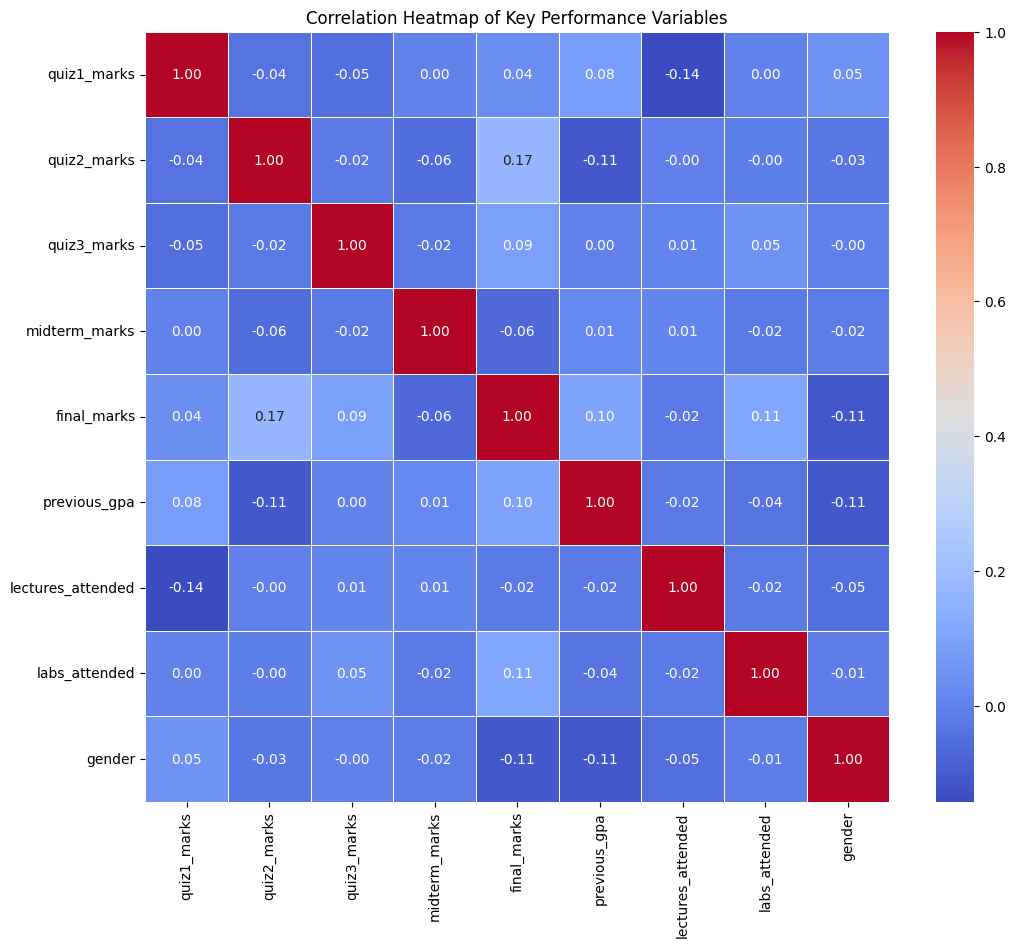

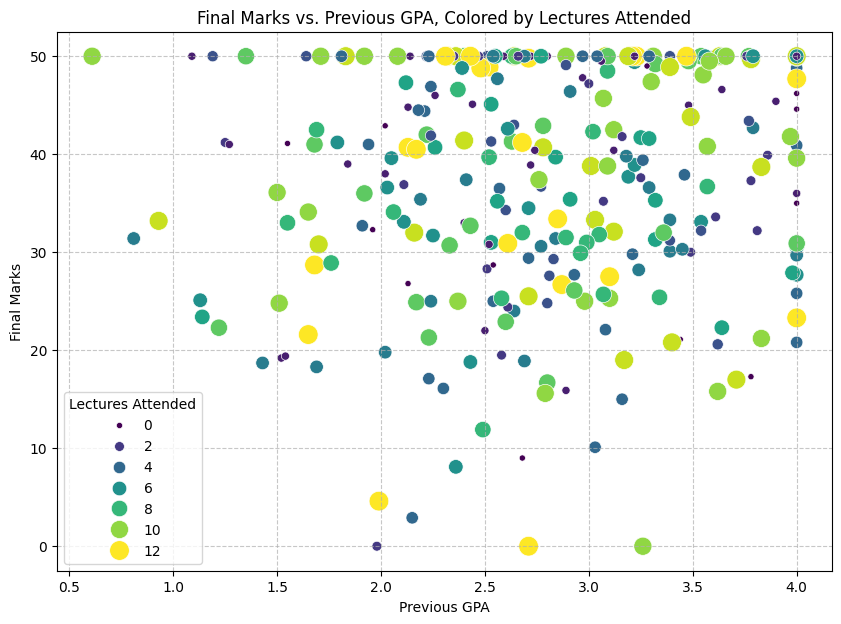

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Correlation Heatmap among key performance variables ---
performance_vars = ['quiz1_marks', 'quiz2_marks', 'quiz3_marks', 'midterm_marks',
                    'final_marks', 'previous_gpa', 'lectures_attended', 'labs_attended', 'gender']

correlation_matrix = df_encoded[performance_vars].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Key Performance Variables')
plt.show()

# --- 2. Scatter plot of previous_gpa vs final_marks colored by lecture_attendance_rate ---
plt.figure(figsize=(10, 7))
scatter_plot = sns.scatterplot(data=df_encoded, x='previous_gpa', y='final_marks', hue='lectures_attended', palette='viridis', size='lectures_attended', sizes=(20, 200))
plt.title('Final Marks vs. Previous GPA, Colored by Lectures Attended')
plt.xlabel('Previous GPA')
plt.ylabel('Final Marks')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Lectures Attended')
plt.show()

The data visualizations show that participants' Final Marks tend to be very high (many clustering around 50). The scatter plot indicates that high lecture attendance (10–12 sessions) correlates with achieving the highest marks for most students, although students with an excellent Previous GPA can sometimes attain top marks with lower attendance. However, the correlation heatmap reveals that there is almost no strong linear relationship between Final Marks and other component scores (such as quizzes, midterm exams) or background factors (like Previous GPA or attendance). This implies that success in this course is multifactorial and is not easily predicted by any single academic performance metric alone.

# DATA STANDARDIZATION

In [14]:
scaler = StandardScaler()

df_transformed = df_encoded.copy()

# Apply StandardScaler to the identified numerical columns
df_transformed = scaler.fit_transform(df_transformed)

# Convert the numpy array back to a DataFrame with original column names for display
df_transformed = pd.DataFrame(df_transformed, columns=df_encoded.columns)

# Display the head of the transformed DataFrame to verify
print("DataFrame after standardizing numerical columns:")
df_transformed.head()

DataFrame after standardizing numerical columns:


,age,gender,quiz1_marks,quiz2_marks,quiz3_marks,midterm_marks,final_marks,previous_gpa,lectures_attended,labs_attended
0,-1.139540,1.033908,0.463198,-0.069135,0.713452,1.214638,-0.074297,-0.322683,-0.541191,-1.065997
1,-0.245783,1.033908,1.706127,0.843441,-0.505808,0.657631,-0.371484,-0.555091,-1.347601,0.954850
2,-1.139540,-0.967204,0.152466,-1.935767,-1.909804,-0.674341,-1.067750,0.251502,-1.616404,-1.571208
3,-0.245783,1.033908,-1.276902,-1.396518,1.637133,-0.274750,0.307801,-1.539408,0.802826,-1.571208
4,-0.245783,-0.967204,-0.841877,0.179750,-1.281700,0.463890,-0.541305,-0.377367,0.265219,0.449638


#  PRINCIPAL COMPONENT ANALYSIS


Ref: https://statisticsglobe.com/principal-component-analysis-python

First, we should choose the ideal number of components before interpreting the results. One alternative is to conduct a PCA for all or an arbitrarily large number of components, then visualize the percentage of explained variance or the eigenvalues per component using a scree plot. Based on the graph, the optimal number can be selected. Let’s run our PCA for ten components!

In [15]:
pca = PCA(n_components=10) #why 10 bcs that is total column we have

pca.fit_transform(df_transformed)

array([[-0.97007566,  0.2512717 , -0.25805316, ...,  0.85514088,
         0.45257755, -0.12896213],
       [-0.45724346,  1.36835954, -1.83594652, ...,  0.2551258 ,
         0.22929964, -0.80266358],
       [-1.96403679,  1.12191215,  1.15890334, ..., -1.86424152,
         0.21494869,  0.84807189],
       ...,
       [ 1.45037555, -1.72779316, -0.85169893, ..., -2.05382793,
        -0.84592089, -0.09354937],
       [ 0.19650367,  0.58542457, -1.07754827, ...,  0.28224409,
        -1.59742038, -1.04536431],
       [ 0.4313977 , -0.12781585, -0.27204428, ...,  0.95386868,
        -0.22568525,  0.57699358]])

Once we have our PCA done, we can extract the proportion of variance explained and the eigenvalues as follows.

In [16]:
prop_var = pca.explained_variance_ratio_
eigenvalues = pca.explained_variance_

We will plot the scree plot using the proportion of variance explained.

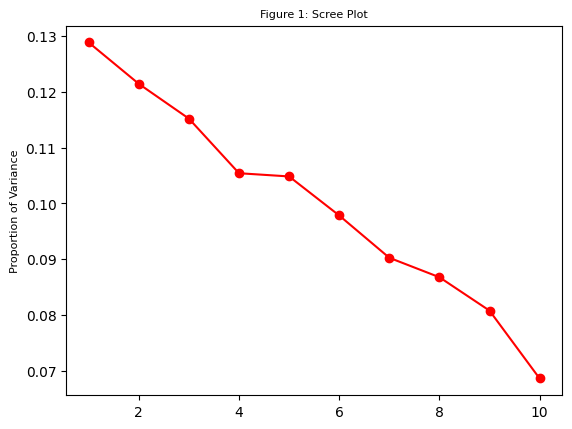

In [17]:
PC_numbers = np.arange(pca.n_components_) + 1

plt.plot(PC_numbers,
         prop_var,
         'ro-')
plt.title('Figure 1: Scree Plot', fontsize=8)
plt.ylabel('Proportion of Variance', fontsize=8)
plt.show()

In [18]:
pca_full = PCA().fit(df_transformed)
explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

print("\nExplained variance per PC (percent) & cumulative:")
for i, (e, c) in enumerate(zip(explained*100, cum_explained*100), start=1):
    print(f"PC{i:02d}: {e:.2f}%  |  Cumulative: {c:.2f}%")


Explained variance per PC (percent) & cumulative:
PC01: 12.88%  |  Cumulative: 12.88%
PC02: 12.14%  |  Cumulative: 25.02%
PC03: 11.52%  |  Cumulative: 36.54%
PC04: 10.54%  |  Cumulative: 47.08%
PC05: 10.48%  |  Cumulative: 57.57%
PC06: 9.78%  |  Cumulative: 67.35%
PC07: 9.03%  |  Cumulative: 76.38%
PC08: 8.68%  |  Cumulative: 85.06%
PC09: 8.08%  |  Cumulative: 93.14%
PC10: 6.86%  |  Cumulative: 100.00%


Based on the result, the 8 principal components account for 12.88% + 12.14% + 11.52% + 10.54% + 10.48% + 9.78% + 9.03% + 8.68%= 85.06% of the variance in the data.

Since 85.06% is a considerable amount, it is sufficient to retain the eight principal components in the analysis.

In [19]:
pca = PCA(n_components=8)
PC = pca.fit_transform(df_transformed)

Let’s store the component scores in a DataFrame and check it via the head() method!

In [20]:
df_pca = pd.DataFrame(data = PC, columns = ['PC1', 'PC2', 'PC3', 'PC4','PC5', 'PC6', 'PC7', 'PC8'])

df_pca.head(5)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,-0.970076,0.251272,-0.258053,-0.062800,0.222625,0.235991,-1.994340,0.855141
1,-0.457243,1.368360,-1.835947,-0.729976,0.223127,1.337209,-0.170171,0.255126
2,-1.964037,1.121912,1.158903,-2.088251,-0.433858,-0.993234,-0.394735,-1.864242
3,-0.905380,-1.742435,-0.160315,1.173438,0.828061,-1.455974,-1.314544,0.528984
4,-0.263028,-0.942491,0.606325,-0.768840,-0.450677,1.027836,0.575022,-0.855673


Now, we can form the biplot. For further information on how to do this, see Biplot in Python. Here, we will use a user-defined biplot() function for the implementation.

In [21]:
def biplot(score,coef,labels=None, colors=None):

    xs = score[:,0]
    ys = score[:,1]
    n = coef.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())

    if colors is not None:
        unique_clusters = np.unique(colors)
        for cluster_label in unique_clusters:
            # Filter points belonging to the current cluster
            cluster_mask = (colors == cluster_label)
            plt.scatter(xs[cluster_mask] * scalex,
                        ys[cluster_mask] * scaley,
                        s=5,
                        label=f'Cluster {int(cluster_label)}')
        plt.legend()
    else:
        plt.scatter(xs * scalex,ys * scaley,
                    s=5,
                    color='orange') # Changed 'color' to 'c' and used 'colors' parameter

    for i in range(n):
        plt.arrow(0, 0, coef[i,0],
                  coef[i,1],color = 'purple',
                  alpha = 0.5)
        plt.text(coef[i,0]* 1.2, # Adjusted position
                 coef[i,1] * 1.2, # Adjusted position
                 labels[i],
                 color = 'darkblue',
                 ha = 'center',
                 va = 'center')
    # --------------------------------------
    # ADD DOTTED REFERENCE LINES (like example)
    # --------------------------------------
    plt.axhline(0, color='black', linestyle='dotted', linewidth=1)
    plt.axvline(0, color='black', linestyle='dotted', linewidth=1)

    plt.xlabel("PC{}".format(1))
    plt.ylabel("PC{}".format(2))


After defining our function, we just have to call it.



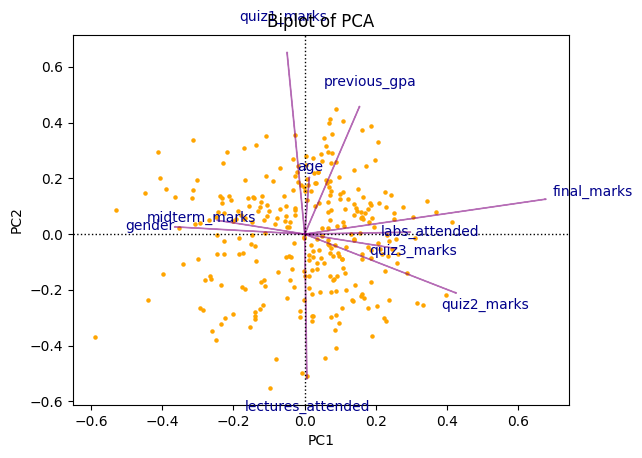

In [22]:
plt.title('Biplot of PCA')

biplot(PC,
       np.transpose(pca.components_),
       list(df_transformed.columns))

## What Does PC1 (Principal Component 1) Represent?
Representation: PC1 (the horizontal axis) primarily represents success or performance associated with the final assessment.

Key Variables:

final_marks has the longest and most positive vector along PC1. This is the most important and highest contributing variable to PC1.

labs_attended and quiz2_marks also contribute positively.

midterm_marks contributes negatively (in the opposite direction).

Conclusion: PC1 can be interpreted as the dimension of Final Mark Achievement Supported by Lab/Quiz 2 Performance.

## What Does PC2 (Principal Component 2) Represent?
Representation: PC2 (the vertical axis) appears to represent a combination of previous academic ability and attendance frequency.

Key Variables:

previous_gpa and age have the longest positive vectors along PC2.

lectures_attended has the longest negative vector (contributing strongly, but in the opposite direction).

Conclusion: PC2 can be interpreted as the dimension that compares Prior Academic Ability (GPA) and Age against Lecture Attendance.

#  K-MEANS CLUSTERING

You need to decide how many clusters (K) you want to create. One way to do this is by using the elbow method, which plots the within-cluster sum of squares (WCSS) for different values of K and looks for the "elbow" point where the WCSS starts to level off.

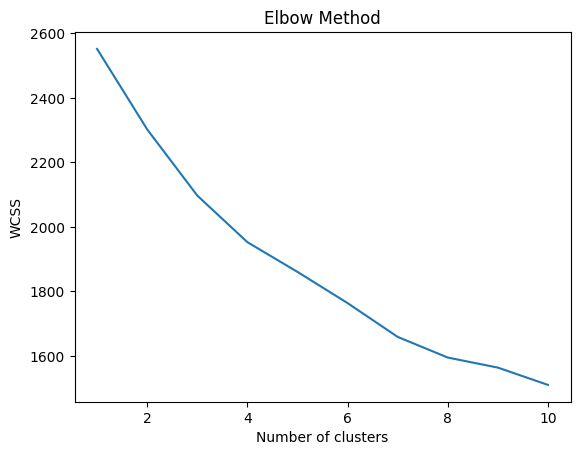

In [23]:
wcss = []
for i in range(1, 11):   #clusters 1-10
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_pca)
    wcss.append(kmeans.inertia_)

# Plot the elbow method graph
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [24]:
# Create a DataFrame to display the WCSS values for each number of clusters
wcss_table = pd.DataFrame({
    "Number of Clusters": range(1, 11),
    "WCSS": wcss
})

# Display the table
print(wcss_table)

   Number of Clusters         WCSS
0                   1  2551.662715
1                   2  2302.291126
2                   3  2097.107129
3                   4  1952.708394
4                   5  1860.515083
5                   6  1763.806878
6                   7  1659.037766
7                   8  1595.024202
8                   9  1563.845563
9                  10  1510.186332


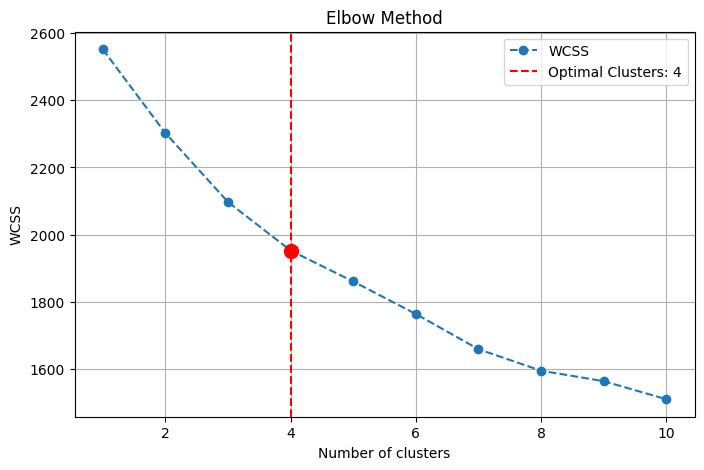

The optimal number of clusters is: 4


In [25]:
from kneed import KneeLocator  # Library to detect the "knee" point

# Example WCSS values and cluster numbers
clusters = range(1, 11)

# Automatically find the elbow point using the KneeLocator
knee_locator = KneeLocator(clusters, wcss, curve="convex", direction="decreasing")
optimal_clusters = knee_locator.knee

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(clusters, wcss, marker='o', linestyle='--', label="WCSS")
plt.axvline(optimal_clusters, linestyle='--', color='red', label=f'Optimal Clusters: {optimal_clusters}')
plt.scatter(optimal_clusters, wcss[optimal_clusters-1], c='red', s=100, zorder=5)  # Highlight elbow point
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.legend()
plt.grid(True)
plt.show()

# Print the optimal number of clusters
print(f"The optimal number of clusters is: {optimal_clusters}")


In [26]:
# Fit K-Means to the data with optimal cluster
kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++',random_state=42)
kmeans_cluster = kmeans.fit_predict(df_pca)

# Add the cluster labels to the DataFrame
df['KMeans'] = kmeans_cluster
df_transformed['KMeans'] = kmeans_cluster

In [27]:
# Evaluation
ss = silhouette_score(df_pca, kmeans_cluster)
print(ss)

0.10373863440575633


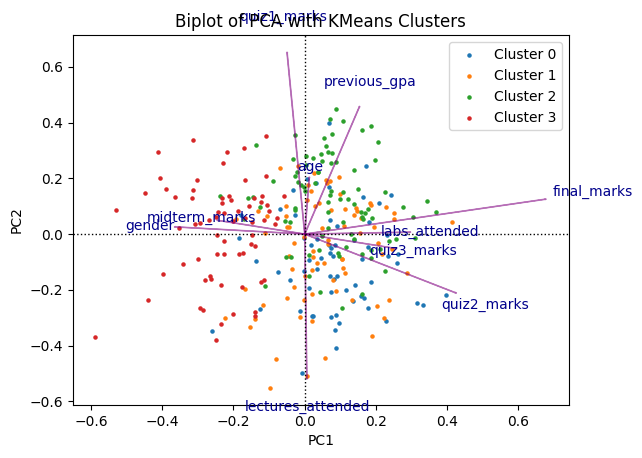

In [28]:
plt.title('Biplot of PCA with KMeans Clusters')
biplot(PC,
       np.transpose(pca.components_),
       list(df_transformed.columns),
       colors=df_transformed['KMeans'])
plt.show()

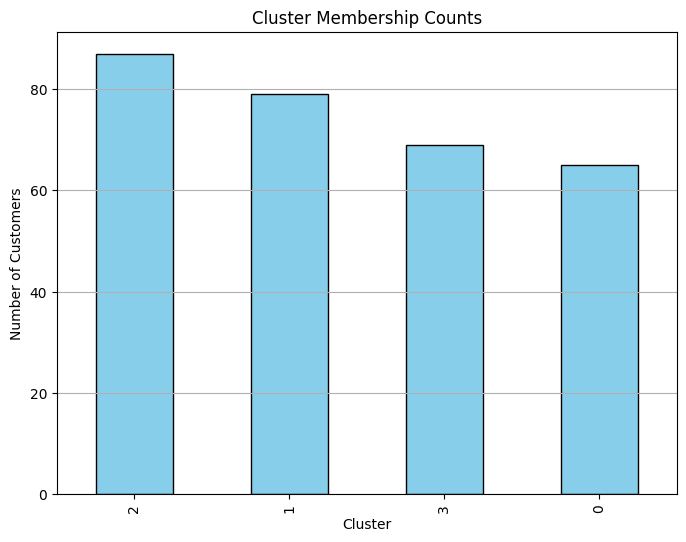

In [30]:
cluster_counts = df['KMeans'].value_counts()

plt.figure(figsize=(8, 6))
cluster_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Cluster Membership Counts')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.grid(axis='y')
plt.show()

In [33]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

# Kode agregasi Anda
cluster_summary = df.groupby('KMeans').agg({
    'gender': [('mode', lambda x: x.mode()[0]), 'count'],
    'age': ['mean', 'std', 'min', 'max'],
    'quiz1_marks': ['mean', 'std', 'min', 'max'],
    'quiz2_marks': ['mean', 'std', 'min', 'max'],
    'quiz3_marks': ['mean', 'std', 'min', 'max'],
    'midterm_marks': ['mean', 'std', 'min', 'max'],
    'final_marks': ['mean', 'std', 'min', 'max'],
    'previous_gpa': ['mean', 'std', 'min', 'max'],
    'lectures_attended': ['mean', 'std', 'min', 'max'],
    'labs_attended': ['mean', 'std', 'min', 'max'],
})

# Rename the index to 'cluster' for clarity
cluster_summary = cluster_summary.rename_axis('Cluster')

# Display the cluster summary
display(cluster_summary)

gender          age               quiz1_marks                   \
           mode count   mean   std min max        mean   std  min   max   
Cluster                                                                   
0        Female    65  20.35  1.96  18  25        6.50  1.49  2.8  10.0   
1          Male    79  21.42  2.20  18  25        7.11  1.44  3.6  10.0   
2        Female    87  22.89  1.83  18  25        7.68  1.61  3.8  10.0   
3          Male    69  21.14  2.20  18  25        7.59  1.67  3.6  10.0   

        quiz2_marks                  quiz3_marks                   \
               mean   std  min   max        mean   std  min   max   
Cluster                                                             
0              6.44  2.16  1.0  10.0        4.01  2.27  0.0   9.4   
1              6.77  2.37  1.5  10.0        6.38  2.57  0.0  10.0   
2              5.52  2.34  1.1  10.0        6.87  2.35  0.8  10.0   
3              4.73  2.27  0.0  10.0        4.04  2.30  0.0   9.0   

        midterm_marks                  final_marks                     \
                 mean   std  min   max        mean    std   min   max   
Cluster                                                                 
0               17.96  8.36  0.0  30.0       40.04  10.62  11.9  50.0   
1               14.01  7.64  0.0  30.0       40.71   9.01  17.1  50.0   
2               23.78  5.84  6.0  30.0       40.98   9.72  10.1  50.0   
3               23.88  6.78  2.0  30.0       26.51  11.71   0.0  50.0   

        previous_gpa                  lectures_attended                \
                mean   std   min  max              mean   std min max   
Cluster                                                                 
0               2.96  0.71  1.14  4.0              7.69  3.67   0  12   
1               2.42  0.77  0.61  4.0              5.62  3.69   0  12   
2               3.10  0.61  1.27  4.0              4.98  3.59   0  12   
3               2.73  0.65  1.43  4.0              6.19  3.49   0  12   

        labs_attended                
                 mean   std min max  
Cluster                              
0                2.88  1.92   0   6  
1                3.78  1.77   0   6  
2                3.59  1.84   0   6  
3                1.96  1.93   0   6

# Cluster Profiling & Educational Recommendations

# Profil Klaster dan Rekomendasi Pendidikan
Biplot PCA dengan K-Means Clustering membagi peserta menjadi empat kelompok utama. Posisi kelompok (klaster) pada biplot menjelaskan bagaimana mereka berbeda berdasarkan kombinasi variabel asli, terutama yang diwakili oleh PC1 (Nilai Akhir) dan PC2 (IPK Sebelumnya/Usia vs. Kehadiran Kuliah).

## 5.1 Profil Setiap Klaster
### Klaster 2 : Siswa Berprestasi Tinggi (Berbasis IPK)
Deskripsi: Kelompok ini berada di kuadran Kanan Atas (positif di PC1 dan PC2). Mereka ditandai dengan IPK Sebelumnya (previous_gpa) yang tinggi dan usia yang lebih tua, serta menunjukkan kinerja yang sangat baik dalam kursus ini, diwakili oleh vektor Nilai Akhir (final_marks) yang tinggi dan Kehadiran Lab (labs_attended) yang tinggi.

Inti Profil: Ini adalah siswa berprestasi tinggi yang konsisten yang berhasil memanfaatkan keterampilan akademik mereka yang sudah mapan.

### Klaster 3 : Siswa Berisiko (At-Risk)
Deskripsi: Kelompok ini tersebar di kuadran Kiri Bawah (negatif di PC1 dan PC2). Mereka dicirikan oleh skor Kehadiran Kuliah (lectures_attended) yang rendah dan nilai yang jauh dari final_marks. Mereka juga memiliki posisi yang berlawanan dengan Nilai Tengah Semester (midterm_marks) yang rendah.

Inti Profil: Ini adalah siswa yang berisiko gagal karena kurangnya keterlibatan (kehadiran) dan kinerja yang buruk dalam penilaian formatif.

### Klaster 0 : Siswa Unggul Berpotensi Rendah
Deskripsi: Kelompok ini berada di kuadran Kiri Atas (negatif di PC1, positif di PC2). Mereka memiliki skor PC2 yang tinggi, menunjukkan IPK Sebelumnya yang tinggi dan usia yang lebih tua. Namun, mereka cenderung menjauhi vektor final_marks dan labs_attended (PC1 negatif), dan berada di sekitar midterm_marks yang rendah.

Inti Profil: Ini adalah siswa yang seharusnya berhasil berdasarkan IPK mereka, tetapi keterlibatan praktis (labs_attended) dan kinerja kursus mereka (terutama midterm) saat ini tidak sesuai dengan potensi mereka.

###Klaster 1 : Siswa Kinerja Rata-Rata/Campuran
Deskripsi: Kelompok ini terpusat di sekitar titik nol (0, 0) pada biplot. Mereka tidak memiliki karakteristik yang sangat kuat di sepanjang PC1 atau PC2.

Inti Profil: Kelompok ini terdiri dari siswa rata-rata yang kinerjanya tidak luar biasa tinggi atau sangat rendah dalam dimensi utama.



## 5.2 Hubungan Klaster dengan PCA
Biplot ini menunjukkan pemisahan yang jelas:

PC1 memisahkan Klaster yang berhasil dalam kursus ini (Klaster 2) dari Klaster yang tidak (Klaster 3 dan 0), terutama melalui skor final_marks dan labs_attended (positif) versus midterm_marks (negatif).

PC2 memisahkan siswa yang membawa keunggulan akademik sebelumnya (previous_gpa) (Klaster 0 dan 2) dari siswa yang memiliki kehadiran kuliah yang rendah (Klaster 3). Klaster 0 dan 2 sama-sama memiliki potensi, tetapi posisi mereka yang berbeda pada PC1 menunjukkan hasil akhir mereka berbeda.

Siswa Berisiko (Klaster 3) terlempar jauh dari sumbu final_marks, sementara Siswa Berprestasi Tinggi (Klaster 2) berada paling dekat dengan sumbu tersebut, memvalidasi korelasi positif yang kuat antara karakteristik Klaster 1 dengan kesuksesan kursus.



## 5.3 Rekomendasi Aksi yang Konkret
Berdasarkan pemrofilan klaster, berikut adalah tiga rekomendasi yang dapat ditindaklanjuti untuk universitas:

### 1. Implementasi Program Intervensi Dini & Wajib untuk Klaster 3
Tautan: Klaster 3 dicirikan oleh lectures_attended yang rendah dan kinerja ujian tengah semester yang buruk, menempatkan mereka pada risiko.

Rekomendasi: Segera setelah nilai midterm dirilis atau tingkat kehadiran turun di bawah 50%, picu Intervensi Bertarget Cepat. Ini harus mencakup pembuatan jadwal belajar wajib dengan tutor, di mana keikutsertaan diintegrasikan dengan sistem akademik mereka (misalnya, menjadi prasyarat untuk sesi praktik tambahan). Fokus pada peningkatan kehadiran dan pemahaman konsep dasar.

### 2. Program Mentoring Kinerja-ke-Potensi untuk Klaster 0
Tautan: Klaster 2 memiliki IPK Sebelumnya yang tinggi tetapi kinerja kursus saat ini dan keterlibatan praktis yang rendah (jauh dari labs_attended dan final_marks). Mereka memiliki potensi tetapi tidak berhasil.

Rekomendasi: Bentuk Program Mentoring Kinerja di mana mereka dipasangkan dengan mentor akademik atau senior yang sukses (idealnya dari Klaster 1). Fokus mentoring harus pada keterampilan aplikasi dan studi yang relevan dengan laboratorium/praktik untuk menjembatani kesenjangan antara pengetahuan teoritis mereka (yang ditunjukkan oleh IPK tinggi) dan kinerja ujian kursus yang sebenarnya.

### 3. Program Penghargaan dan Peluang Penelitian Tingkat Lanjut untuk Klaster 2
Tautan: Klaster 1 adalah berkinerja terbaik yang memiliki nilai tertinggi di sebagian besar variabel kunci (final_marks, previous_gpa).

Rekomendasi: Tawarkan Program Kehormatan Kursus (Course Honors Program) atau kesempatan Asisten Penelitian (RA) yang dibayar khusus untuk siswa dari klaster ini. Hal ini memberikan pengakuan, mempertahankan keterlibatan mereka, dan memanfaatkan bakat mereka untuk meningkatkan kualitas riset dan pengajaran universitas.